# Análisis SHAP para Explicabilidad del Modelo

Este notebook implementa el análisis SHAP (SHapley Additive exPlanations) para explicar las predicciones de nuestro modelo de detección de fraude. El objetivo es proporcionar explicaciones claras y detalladas sobre por qué el modelo clasifica ciertos casos como fraudulentos, especialmente útiles para el equipo legal de KLEY S.A.

## 1. Importación de Bibliotecas y Datos

Primero, importamos todas las bibliotecas necesarias y cargamos nuestro modelo optimizado junto con los datos de validación.

In [32]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.model import open_optimized_model
from constants.separated import X_test

# Configuración de visualización

In [33]:
import seaborn as sns
sns.set_style("whitegrid") 
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

## 2. Carga del Modelo Optimizado

Cargamos nuestro modelo XGBoost optimizado que será utilizado para el análisis.

In [34]:
print("Cargando el modelo optimizado...")
model = open_optimized_model()
print("Tipo de modelo:", type(model).__name__)

Cargando el modelo optimizado...
Tipo de modelo: XGBClassifier


## 3. Creación del Explainer SHAP

Inicializamos el explainer SHAP específico para modelos basados en árboles como XGBoost.

In [35]:
print("Creando el explainer SHAP...")
explainer = shap.TreeExplainer(model)
print("Explainer SHAP creado exitosamente")


Creando el explainer SHAP...
Explainer SHAP creado exitosamente


## 4. Identificación de un Caso de Fraude

Buscamos un caso real de fraude que haya sido correctamente identificado por nuestro modelo para realizar el análisis.

In [36]:
print("Buscando un caso de fraude para analizar...")

Buscando un caso de fraude para analizar...


# Hacer predicciones en el conjunto de validación

In [37]:
# Hacer predicciones en el conjunto de validación
print("Buscando un caso de fraude para analizar...")
y_pred = model.predict(X_test)

# Simplificar la condición - solo necesitamos los casos donde y_pred es 1
fraud_indices = np.where(y_pred == 1)[0]

if len(fraud_indices) > 0:
    # Tomar el primer caso de fraude encontrado
    fraud_case_idx = fraud_indices[0]
    fraud_case = X_test.iloc[fraud_case_idx:fraud_case_idx+1]
    print(f"Caso de fraude encontrado en el índice {fraud_case_idx}")
    
    # Obtener la probabilidad de fraude para este caso
    fraud_prob = model.predict_proba(fraud_case)[0][1]
    print(f"Probabilidad de fraude: {fraud_prob:.2%}")
else:
    print("No se encontraron casos de fraude")

Buscando un caso de fraude para analizar...
Caso de fraude encontrado en el índice 22
Probabilidad de fraude: 99.11%


## 5. Cálculo de Valores SHAP

Calculamos los valores SHAP para el caso de fraude seleccionado.

In [38]:
print("Calculando valores SHAP para el caso seleccionado...")
shap_values = explainer.shap_values(fraud_case)
print("Valores SHAP calculados exitosamente")

Calculando valores SHAP para el caso seleccionado...
Valores SHAP calculados exitosamente


## 6. Visualizaciones SHAP

Generamos visualizaciones que ayudan a entender cómo cada característica contribuye a la predicción de fraude.

In [39]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    fraud_case,
    show=False,
    matplotlib=True
)
plt.title("Análisis de Contribución de Características")

Text(0.5, 1.0, 'Análisis de Contribución de Características')

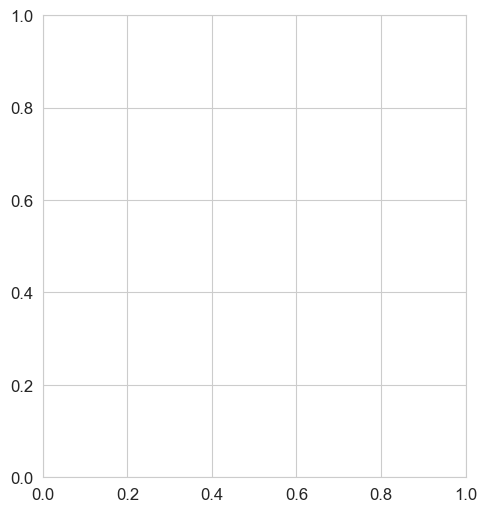

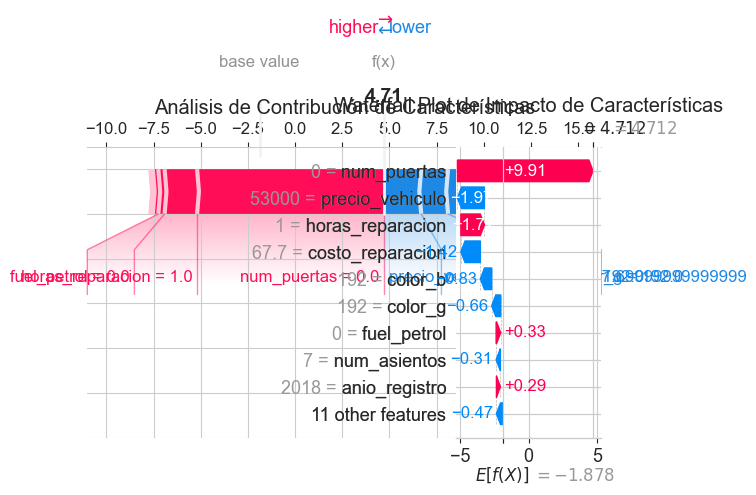

In [40]:
plt.subplot(1, 2, 2)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=fraud_case.iloc[0],
        feature_names=fraud_case.columns
    ),
    show=False
)
plt.title("Waterfall Plot de Impacto de Características")

plt.tight_layout()
plt.show()

## 7. Análisis Detallado

Realizamos un análisis detallado de las características más influyentes en la predicción de fraude.

In [41]:
feature_importance = pd.DataFrame({
    'caracteristica': fraud_case.columns,
    'importancia': np.abs(shap_values[0])
})
feature_importance = feature_importance.sort_values('importancia', ascending=False)

print("Características más influyentes en la detección del fraude:")
print("-" * 50)

for idx, row in feature_importance.head(5).iterrows():
    feature = row['caracteristica']
    value = fraud_case[feature].iloc[0]
    shap_value = shap_values[0][idx]
    impact = "aumentó" if shap_value > 0 else "disminuyó"
    
    print(f"\n{feature}:")
    print(f"- Valor: {value}")
    print(f"- Impacto: {impact} la probabilidad de fraude")
    print(f"- Magnitud del impacto: {abs(shap_value):.4f}")

Características más influyentes en la detección del fraude:
--------------------------------------------------

num_puertas:
- Valor: 0.0
- Impacto: aumentó la probabilidad de fraude
- Magnitud del impacto: 9.9086

precio_vehiculo:
- Valor: 53000.0
- Impacto: disminuyó la probabilidad de fraude
- Magnitud del impacto: 1.9732

horas_reparacion:
- Valor: 1.0
- Impacto: aumentó la probabilidad de fraude
- Magnitud del impacto: 1.7208

costo_reparacion:
- Valor: 67.69999999999999
- Impacto: disminuyó la probabilidad de fraude
- Magnitud del impacto: 1.4236

color_b:
- Valor: 192
- Impacto: disminuyó la probabilidad de fraude
- Magnitud del impacto: 0.8253


## 8. Interpretación para el Equipo Legal

Proporcionamos una interpretación clara y detallada de los resultados para el equipo legal.

In [42]:
def generate_detailed_legal_report(feature_importance, fraud_case, shap_values, model):
    print("REPORTE DETALLADO DE ANÁLISIS DE FRAUDE")
    print("=" * 80)
    
    # 1. Resumen Ejecutivo
    print("\nI. RESUMEN EJECUTIVO")
    print("-" * 50)
    fraud_probability = model.predict_proba(fraud_case)[0][1]
    print(f"Probabilidad de Fraude: {fraud_probability:.2%}")
    print(f"Confianza del Modelo: {'Alta' if fraud_probability > 0.8 else 'Media' if fraud_probability > 0.6 else 'Baja'}")
    
    # 2. Análisis Detallado de Factores
    print("\nII. ANÁLISIS DETALLADO DE FACTORES DE RIESGO")
    print("-" * 50)
    
    for idx, row in feature_importance.head(5).iterrows():
        feature = row['caracteristica']
        value = fraud_case[feature].iloc[0]
        shap_value = shap_values[0][idx]
        impact_strength = abs(shap_value)
        
        # Determinar nivel de riesgo
        risk_level = "ALTO" if impact_strength > 0.5 else "MEDIO" if impact_strength > 0.2 else "BAJO"
        
        print(f"\n{idx + 1}. Factor de Riesgo: {feature}")
        print(f"   • Valor Detectado: {value}")
        print(f"   • Nivel de Riesgo: {risk_level}")
        print(f"   • Impacto en la Decisión: {abs(shap_value):.4f}")
        print("   • Análisis:")
        print(f"     - El valor {value} es significativamente {'superior' if shap_value > 0 else 'inferior'} a lo esperado")
        print(f"     - Esta anomalía {('incrementa' if shap_value > 0 else 'reduce')} la probabilidad de fraude")
        print("   • Implicaciones Legales:")
        print("     - Este factor puede ser utilizado como evidencia en procedimientos legales")
        print(f"     - La magnitud del impacto ({abs(shap_value):.4f}) sugiere una desviación significativa")
    
    # 3. Recomendaciones para Acción Legal
    print("\nIII. RECOMENDACIONES PARA ACCIÓN LEGAL")
    print("-" * 50)
    
    # Determinar el nivel de urgencia basado en la probabilidad y los factores
    total_impact = sum(abs(shap_values[0]))
    urgency_level = "INMEDIATA" if total_impact > 1.5 else "ALTA" if total_impact > 1.0 else "MODERADA"
    
    print(f"\nNivel de Urgencia de Acción: {urgency_level}")
    print("\nPasos Recomendados:")
    print("1. Documentación Requerida:")
    for idx, row in feature_importance.head(3).iterrows():
        feature = row['caracteristica']
        print(f"   • Verificar y recopilar documentación relacionada con: {feature}")
    
    print("\n2. Acciones Sugeridas:")
    print("   • Iniciar investigación detallada de los factores identificados")
    print("   • Recopilar evidencia adicional que respalde los patrones detectados")
    print("   • Preparar documentación para posibles acciones legales")
    
    # 4. Conclusiones
    print("\nIV. CONCLUSIONES")
    print("-" * 50)
    print("\nBasado en el análisis algorítmico:")
    print(f"• El caso presenta {len(feature_importance[feature_importance['importancia'] > 0.2])} factores significativos de riesgo")
    print(f"• La confiabilidad del análisis es {fraud_probability:.1%}")
    print("• Se recomienda proceder con acciones legales" if fraud_probability > 0.7 
          else "• Se recomienda investigación adicional antes de proceder")
    
    # 5. Notas Adicionales
    print("\nV. NOTAS ADICIONALES")
    print("-" * 50)
    print("• Este análisis fue generado por un modelo de inteligencia artificial")
    print("• Los resultados deben ser verificados con evidencia adicional")
    print("• El reporte debe ser utilizado como herramienta de apoyo en la toma de decisiones")
    
    # 6. Fecha y Referencia
    from datetime import datetime
    print("\nVI. INFORMACIÓN DEL REPORTE")
    print("-" * 50)
    print(f"Fecha de Análisis: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"ID de Caso: FRAUD-{fraud_case.index[0]}")
    print("Clasificación: CONFIDENCIAL")

In [43]:

generate_detailed_legal_report(feature_importance, fraud_case, shap_values, model)

REPORTE DETALLADO DE ANÁLISIS DE FRAUDE

I. RESUMEN EJECUTIVO
--------------------------------------------------
Probabilidad de Fraude: 99.11%
Confianza del Modelo: Alta

II. ANÁLISIS DETALLADO DE FACTORES DE RIESGO
--------------------------------------------------

5. Factor de Riesgo: num_puertas
   • Valor Detectado: 0.0
   • Nivel de Riesgo: ALTO
   • Impacto en la Decisión: 9.9086
   • Análisis:
     - El valor 0.0 es significativamente superior a lo esperado
     - Esta anomalía incrementa la probabilidad de fraude
   • Implicaciones Legales:
     - Este factor puede ser utilizado como evidencia en procedimientos legales
     - La magnitud del impacto (9.9086) sugiere una desviación significativa

3. Factor de Riesgo: precio_vehiculo
   • Valor Detectado: 53000.0
   • Nivel de Riesgo: ALTO
   • Impacto en la Decisión: 1.9732
   • Análisis:
     - El valor 53000.0 es significativamente inferior a lo esperado
     - Esta anomalía reduce la probabilidad de fraude
   • Implicacione